# Notebook 7 — Final Training & Evaluation

In this notebook, the selected XGBoost model is trained using the
combined Training and Validation datasets.

The final model configuration and classification threshold were
selected in Notebook 6 and will remain fixed.

The workflow is:

1. Load the prepared datasets.
2. Combine the Training and Validation data.
3. Train the final XGBoost model.
4. Generate predictions on the Test set.
5. Apply the selected classification threshold.
6. Evaluate the final model on the Test set.
7. Analyze the final classification performance.
8. Save the final trained model and evaluation results.

The Test set is used only for the final evaluation and is not used
for further model tuning or parameter selection.


In [2]:
# ============================================================
# Imports
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path
from scipy.sparse import csr_matrix, vstack

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier


# ============================================================
# Paths
# ============================================================

FEATURES_PATH = Path(
    r"C:\Users\user\Desktop\MLOps-Olist\data\features"
)

MODELS_PATH = Path(
    r"C:\Users\user\Desktop\MLOps-Olist\models"
)

REPORTS_PATH = Path(
    r"C:\Users\user\Desktop\MLOps-Olist\reports"
)


# ============================================================
# Load CSR Sparse Matrix
# ============================================================

def load_sparse_matrix(path):
    data = np.load(path, allow_pickle=True)

    matrix = csr_matrix(
        (
            data["data"],
            data["indices"],
            data["indptr"]
        ),
        shape=tuple(data["shape"])
    )

    data.close()

    return matrix


# ============================================================
# Load Feature Matrices
# ============================================================

X_train = load_sparse_matrix(
    FEATURES_PATH / "X_train.npz"
)

X_validation = load_sparse_matrix(
    FEATURES_PATH / "X_validation.npz"
)

X_test = load_sparse_matrix(
    FEATURES_PATH / "X_test.npz"
)


# ============================================================
# Load Labels
# ============================================================

y_train = pd.read_parquet(
    FEATURES_PATH / "y_train.parquet"
).squeeze().to_numpy()

y_validation = pd.read_parquet(
    FEATURES_PATH / "y_validation.parquet"
).squeeze().to_numpy()

y_test = pd.read_parquet(
    FEATURES_PATH / "y_test.parquet"
).squeeze().to_numpy()


# ============================================================
# Verify Original Datasets
# ============================================================

print("Original datasets:")
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_validation.shape, y_validation.shape)
print("Test:", X_test.shape, y_test.shape)


# ============================================================
# Combine Training + Validation
# ============================================================

X_train_full = vstack([
    X_train,
    X_validation
])

y_train_full = np.concatenate([
    y_train,
    y_validation
])


# ============================================================
# Final Dataset
# ============================================================

print("\nFinal training dataset:")
print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)

print("\nTest dataset:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Original datasets:
Train: (67533, 17540) (67533,)
Validation: (14471, 17540) (14471,)
Test: (14472, 17540) (14472,)

Final training dataset:
X_train_full: (82004, 17540)
y_train_full: (82004,)

Test dataset:
X_test: (14472, 17540)
y_test: (14472,)


## 2. Final XGBoost Configuration

The XGBoost configuration selected in Notebook 6 is used for the
final model.

No additional hyperparameter tuning is performed at this stage.

The classification threshold is also fixed at 0.15, based on the
threshold selected using the Validation set in Notebook 6.


In [3]:
FINAL_THRESHOLD = 0.15

final_xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print("Final XGBoost configuration:")
print("n_estimators:", 500)
print("max_depth:", 4)
print("learning_rate:", 0.05)
print("subsample:", 0.8)
print("colsample_bytree:", 0.8)
print("Classification threshold:", FINAL_THRESHOLD)

Final XGBoost configuration:
n_estimators: 500
max_depth: 4
learning_rate: 0.05
subsample: 0.8
colsample_bytree: 0.8
Classification threshold: 0.15


## 3. Train Final XGBoost Model

The final XGBoost model is trained using the combined Training and
Validation datasets.

At this stage, the model parameters are fixed and no further tuning
is performed.


In [4]:
print("Training final XGBoost model...")

final_xgb_model.fit(
    X_train_full,
    y_train_full
)

print("Final XGBoost model training completed successfully.")

Training final XGBoost model...
Final XGBoost model training completed successfully.


## 4. Generate Final Test Predictions

The trained final model is used to generate probability scores for
the Test set.

The fixed classification threshold of 0.15 is then applied to convert
the predicted probabilities into binary class predictions.


In [5]:
# Predict probabilities
test_score_final = final_xgb_model.predict_proba(X_test)[:, 1]

# Apply final threshold
test_pred_final = (
    test_score_final >= FINAL_THRESHOLD
).astype(int)

print("Final Test predictions generated.")
print("Threshold:", FINAL_THRESHOLD)

print("\nPredicted class distribution:")
print(pd.Series(test_pred_final).value_counts().sort_index())

Final Test predictions generated.
Threshold: 0.15

Predicted class distribution:
0    13608
1      864
Name: count, dtype: int64


## 5. Final Test Evaluation

The final model is evaluated on the Test set using the fixed
classification threshold.

The evaluation includes Accuracy, Precision, Recall, F1-score,
ROC-AUC, and Average Precision.


In [6]:
final_test_results = {
    "accuracy": accuracy_score(y_test, test_pred_final),
    "precision": precision_score(
        y_test,
        test_pred_final,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        test_pred_final,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        test_pred_final,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        test_score_final
    ),
    "average_precision": average_precision_score(
        y_test,
        test_score_final
    )
}

final_test_results

{'accuracy': 0.890616362631288,
 'precision': 0.13773148148148148,
 'recall': 0.12434691745036573,
 'f1': 0.13069741900054915,
 'roc_auc': 0.6349067621370427,
 'average_precision': 0.10397311997086062}

In [7]:
final_test_table = pd.DataFrame([final_test_results])

final_test_table.insert(
    0,
    "Model",
    "Final XGBoost"
)

final_test_table["Threshold"] = FINAL_THRESHOLD

display(final_test_table)

,Model,accuracy,precision,recall,f1,roc_auc,average_precision,Threshold
0,Final XGBoost,0.890616,0.137731,0.124347,0.130697,0.634907,0.103973,0.15


## 6. Final Classification Analysis

The classification report provides detailed performance for both
classes.

The confusion matrix shows the number of correctly and incorrectly
classified on-time and late orders.


In [8]:
print("Final XGBoost — Test Classification Report")
print("-" * 50)

print(
    classification_report(
        y_test,
        test_pred_final,
        target_names=["On Time", "Late"],
        digits=4,
        zero_division=0
    )
)

Final XGBoost — Test Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

     On Time     0.9384    0.9449    0.9416     13515
        Late     0.1377    0.1243    0.1307       957

    accuracy                         0.8906     14472
   macro avg     0.5381    0.5346    0.5362     14472
weighted avg     0.8855    0.8906    0.8880     14472



In [9]:
cm_final = confusion_matrix(
    y_test,
    test_pred_final
)

print("Final XGBoost — Test Confusion Matrix")
print("-" * 50)

print(cm_final)

Final XGBoost — Test Confusion Matrix
--------------------------------------------------
[[12770   745]
 [  838   119]]


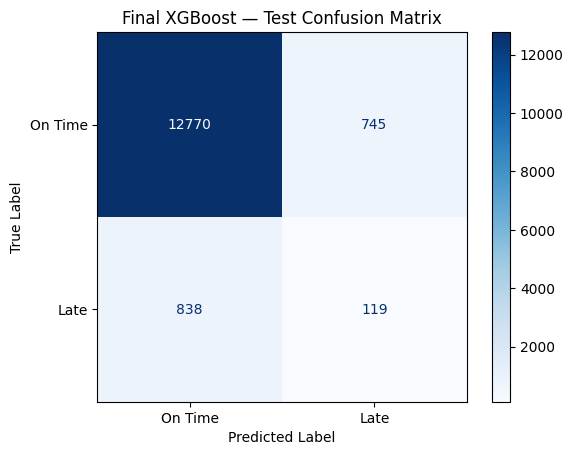

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["On Time", "Late"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Final XGBoost — Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 7. Save Final Model and Results

The final trained XGBoost model is saved for future use.

The final classification threshold and evaluation metrics are also
saved as metadata.


In [10]:
import json

# Save final model
joblib.dump(
    final_xgb_model,
    "final_xgboost_model.joblib"
)

# Save final results and threshold
final_metadata = {
    "model": "XGBoost",
    "n_estimators": 500,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "threshold": FINAL_THRESHOLD,
    "metrics": final_test_results
}

with open(
    "final_xgboost_results.json",
    "w"
) as f:
    json.dump(
        final_metadata,
        f,
        indent=4
    )

print("Final model saved as:")
print("final_xgboost_model.joblib")

print("\nFinal results saved as:")
print("final_xgboost_results.json")

Final model saved as:
final_xgboost_model.joblib

Final results saved as:
final_xgboost_results.json


## 10. Final Model Performance

The final performance of the selected XGBoost model on the Test set is
summarized below.


In [11]:
final_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Average Precision",
        "Threshold"
    ],
    "Final XGBoost": [
        final_test_results["accuracy"],
        final_test_results["precision"],
        final_test_results["recall"],
        final_test_results["f1"],
        final_test_results["roc_auc"],
        final_test_results["average_precision"],
        FINAL_THRESHOLD
    ]
})

final_summary

,Metric,Final XGBoost
0,Accuracy,0.890616
1,Precision,0.137731
2,Recall,0.124347
3,F1-Score,0.130697
4,ROC-AUC,0.634907
5,Average Precision,0.103973
6,Threshold,0.150000


## 11. Validation vs Test Performance

The final model performance on the Validation and Test sets is
compared to assess how well the model generalizes to the later
time period.

A noticeable decrease in performance on the Test set indicates that
the model faces a generalization challenge when applied to later data.


In [13]:
validation_vs_test = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Validation": [
        0.899730,
        0.206239,
        0.307891,
        0.247016,
        0.755802,
        0.163086
    ],
    "Test": [
        final_test_results["accuracy"],
        final_test_results["precision"],
        final_test_results["recall"],
        final_test_results["f1"],
        final_test_results["roc_auc"],
        final_test_results["average_precision"]
    ]
})

display(validation_vs_test)

,Metric,Validation,Test
0,Accuracy,0.899730,0.890616
1,Precision,0.206239,0.137731
2,Recall,0.307891,0.124347
3,F1-Score,0.247016,0.130697
4,ROC-AUC,0.755802,0.634907
5,Average Precision,0.163086,0.103973


## 12. Final Project Conclusion

The late delivery prediction pipeline was successfully completed.

The project followed a time-based machine learning workflow consisting
of data preparation, label creation, exploratory data analysis,
feature engineering, model training, hyperparameter tuning, threshold
optimization, model comparison, and final evaluation.

Logistic Regression and XGBoost were evaluated, with XGBoost providing
the strongest Validation performance. A simple ensemble was also
tested but did not improve the results.

The final XGBoost model was trained using the combined Training and
Validation datasets with the selected configuration:

* n_estimators: 500
* max_depth: 4
* learning_rate: 0.05
* subsample: 0.8
* colsample_bytree: 0.8
* classification threshold: 0.15

On the Test set, the final model achieved:

* Accuracy: 89.06%
* Precision: 13.77%
* Recall: 12.43%
* F1-score: 13.07%
* ROC-AUC: 63.49%
* Average Precision: 10.40%

The results demonstrate that accuracy alone is not an appropriate
measure of success for this highly imbalanced classification problem.
The relatively low Recall and F1-score for the Late class indicate
that the current model has limited ability to identify late deliveries.

The difference between Validation and Test performance also suggests
that temporal distribution shift may affect model generalization.

The final model and evaluation results were saved for future use.
